# Kenyan Tea Price Prediction & Commodity Risk Modeling 🍵🍃

This project aims to predict tea prices using macroeconomic and environmental factors such as:

- USD/KES exchange rate (FX exposure)
- Rainfall (supply-side impact)
- Historical price trends (momentum & volatility)

The model is designed to capture:
- Price volatility
- FX-driven export competitiveness
- Weather-driven production shocks

## Data Loading

We load:
- Tea price data (monthly)
- USD/KES exchange rate (monthly)
- Rainfall data (monthly)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

tea = pd.read_csv("tea_prices.csv")
fx = pd.read_csv("USD_KES_monthly.csv")
rain = pd.read_csv("Kenya_rainfall.csv")

## Data Cleaning

- Convert Date columns to datetime
- Ensure monthly alignment
- Sort data chronologically

In [2]:
tea.info()

<class 'pandas.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    313 non-null    str    
 1   Price   313 non-null    float64
dtypes: float64(1), str(1)
memory usage: 5.0 KB


In [3]:
fx.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      301 non-null    str    
 1   Price     301 non-null    float64
 2   Open      301 non-null    float64
 3   High      301 non-null    float64
 4   Low       301 non-null    float64
 5   Vol.      0 non-null      float64
 6   Change %  301 non-null    str    
dtypes: float64(5), str(2)
memory usage: 16.6 KB


#### Weather Data Fix

In [4]:
rain['Month'] = rain['Month Average'].str.replace(' Average', '')

#### Mapping

In [5]:
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4,
    'May':5, 'Jun':6, 'Jul':7, 'Aug':8,
    'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

rain['Month'] = rain['Month'].map(month_map)

#### Date Column Created

In [6]:
rain['Date'] = pd.to_datetime(dict(year=rain['Year'], month=rain['Month'], day=1))

#### Renamed

In [7]:
rain.rename(columns={'Rainfall - (MM)': 'Rainfall'}, inplace=True)

In [8]:
tea.rename(columns={'Price':'Tea_Price'}, inplace=True)

In [9]:
fx.rename(columns={'Price':'USDKES'}, inplace=True)

In [10]:
rain = rain[['Date', 'Rainfall']]

#### Sorted

In [11]:
rain = rain.sort_values('Date')

In [12]:
# Convert to datetime
tea['Date'] = pd.to_datetime(tea['Date'])
fx['Date'] = pd.to_datetime(fx['Date'])
rain['Date'] = pd.to_datetime(rain['Date'])

# Sort
tea = tea.sort_values('Date')
fx = fx.sort_values('Date')
rain = rain.sort_values('Date')

### Month Alignment 

In [13]:
tea['Date'] = tea['Date'].dt.to_period('M')
fx['Date'] = fx['Date'].dt.to_period('M')
rain['Date'] = rain['Date'].dt.to_period('M')

## Data Merging

We merge datasets on monthly periods using INNER JOIN to ensure no missing alignment.

In [14]:
df = tea.merge(fx, on='Date', how='inner')
df = df.merge(rain, on='Date', how='inner')

## Final Cleaning

In [15]:
# Convert back to timestamp
df['Date'] = df['Date'].dt.to_timestamp()

# Set index
df.set_index('Date', inplace=True)

df.head()

,Tea_Price,USDKES,Open,High,Low,Vol.,Change %,Rainfall
Date,,,,,,,,
2001-01-01,1.9,78.50,78.40,78.50,78.40,NaN,0.58%,73.4348
2001-01-01,1.9,78.10,78.00,78.10,78.00,NaN,-0.51%,73.4348
2001-01-01,1.9,77.80,77.70,77.80,77.70,NaN,-0.38%,73.4348
2001-01-01,1.9,77.55,77.45,77.55,77.45,NaN,-0.32%,73.4348
2001-01-01,1.9,77.90,77.85,77.90,77.85,NaN,0.45%,73.4348


## Exploratory Data Analysis

We analyze trends and relationships between:
- Tea prices
- FX rates
- Rainfall

In [16]:
df.columns

Index(['Tea_Price', 'USDKES', 'Open', 'High', 'Low', 'Vol.', 'Change %',
       'Rainfall'],
      dtype='str')

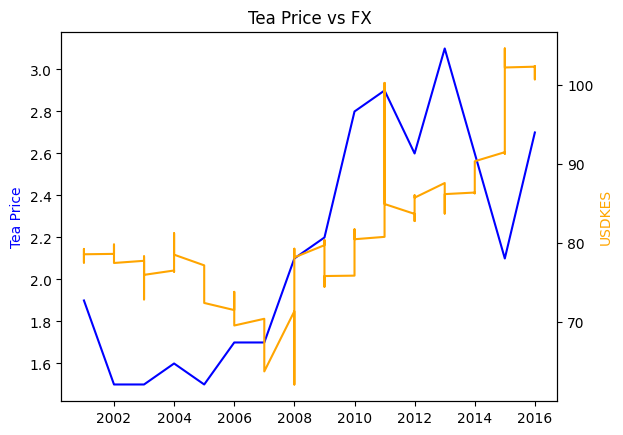

In [17]:
fig, ax1 = plt.subplots()

ax1.plot(df.index, df['Tea_Price'], color='blue')
ax1.set_ylabel('Tea Price', color='blue')

ax2 = ax1.twinx()
ax2.plot(df.index, df['USDKES'], color='orange')
ax2.set_ylabel('USDKES', color='orange')

plt.title("Tea Price vs FX")
plt.show()

## 📊 Tea Price vs USD/KES Exchange Rate Analysis

This visualization compares Kenyan tea prices with the USD/KES exchange rate over time.

### 🔍 Key Observations:

* **Upward Trend in USD/KES:**
  The exchange rate shows a consistent upward trend, indicating a **depreciation of the Kenyan Shilling** against the US Dollar.

* **Tea Price Behavior:**
  Tea prices exhibit **moderate volatility** with a gradual upward movement, but remain relatively stable compared to FX fluctuations.

* **Weak Direct Correlation:**
  While both series increase over time, the relationship is **not strongly linear**, suggesting that tea prices are influenced by multiple factors beyond exchange rates.

* **Possible Economic Interpretation:**
  A higher USD/KES rate can make Kenyan tea more competitive in global markets, potentially increasing demand. However, this effect is not immediately reflected in price movements, indicating the role of other factors such as supply, weather conditions, and auction dynamics.

### 📌 Conclusion:

The exchange rate is an important macroeconomic factor, but **tea price movements are multi-factor driven**, requiring additional features (e.g., lagged prices, volatility, rainfall) for accurate prediction.


In [21]:
df = df[['Tea_Price', 'USDKES', 'Rainfall']]

## ⚙️ Feature Engineering

To improve model performance, we create time-series based features:

* **Lag Features:** Capture past price influence
* **Moving Averages:** Smooth short-term fluctuations
* **Volatility:** Measure price variability
* **FX Returns:** Capture exchange rate changes
* **Trend Indicator:** Difference between short and long-term averages

These features help the model understand temporal patterns without causing data leakage.


In [26]:
# Lag features
df['lag_1'] = df['Tea_Price'].shift(1)
df['lag_2'] = df['Tea_Price'].shift(2)

# Moving averages
df['ma_3'] = df['Tea_Price'].rolling(3).mean()
df['ma_6'] = df['Tea_Price'].rolling(6).mean()

# Volatility
df['volatility'] = df['Tea_Price'].rolling(3).std()

# FX return
df['fx_return'] = df['USDKES'].pct_change()

# Trend
df['trend'] = df['ma_3'] - df['ma_6']

# Drop NaN (important)
df = df.dropna()

In [42]:
df.sample(10)

,Tea_Price,USDKES,Rainfall,lag_1,lag_2,ma_3,ma_6,volatility,fx_return,trend
Date,,,,,,,,,,
2008-01-01,2.1,65.25,26.4445,2.1,2.1,2.1,2.1,0.0,0.049035,0.0
2005-01-01,1.5,73.85,19.1011,1.5,1.5,1.5,1.5,0.0,0.000000,0.0
2007-01-01,1.7,64.35,34.3716,1.7,1.7,1.7,1.7,0.0,-0.038835,0.0
2008-01-01,2.1,68.90,26.4445,2.1,2.1,2.1,2.1,0.0,0.021497,0.0
2004-01-01,1.6,80.36,54.7009,1.6,1.6,1.6,1.6,0.0,0.012984,0.0
2016-01-01,2.7,101.70,56.7251,2.7,2.7,2.7,2.7,0.0,0.001970,0.0
2007-01-01,1.7,66.95,34.3716,1.7,1.7,1.7,1.7,0.0,-0.016165,0.0
2006-01-01,1.7,73.85,22.1909,1.7,1.7,1.7,1.7,0.0,0.023562,0.0
2007-01-01,1.7,67.10,34.3716,1.7,1.7,1.7,1.7,0.0,0.003740,0.0


## 🧪 Train-Test Split

We use a time-based split instead of random splitting to preserve temporal order and avoid data leakage.

* Training Data → Past
* Testing Data → Future


In [43]:
train = df[:'2014']
test = df['2015':]

print(train.shape, test.shape)

(163, 10) (24, 10)


## 🤖 Model Training

We use a Random Forest Regressor to capture non-linear relationships between features and tea prices.


In [44]:
from sklearn.ensemble import RandomForestRegressor

features = ['lag_1','lag_2','ma_3','ma_6','volatility','fx_return','trend']

X_train = train[features]
y_train = train['Tea_Price']

X_test = test[features]
y_test = test['Tea_Price']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 📊 Model Evaluation

We evaluate model performance using:

* **MAE (Mean Absolute Error)**
* **RMSE (Root Mean Squared Error)**

These metrics help assess prediction accuracy.


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.09625000000000157
RMSE: 0.17714636133246806


## 📈 Actual vs Predicted

We compare predicted tea prices with actual values to visually assess model performance.


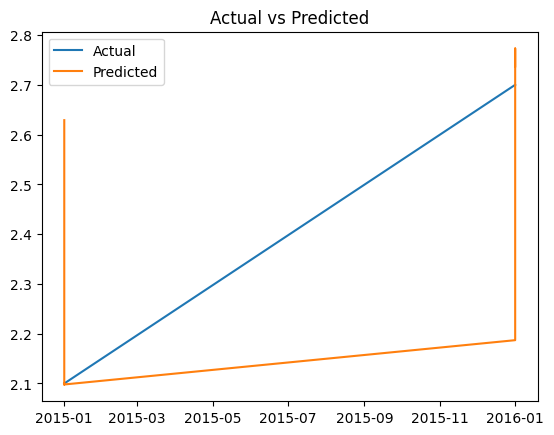

In [46]:
import matplotlib.pyplot as plt

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

## 📉 Linear Regression Baseline Model

To establish a baseline, we train a Linear Regression model.
This helps compare performance against non-linear models like Random Forest.


In [47]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 3.1456319031046104e-16
Linear Regression RMSE: 4.1540741810552243e-16


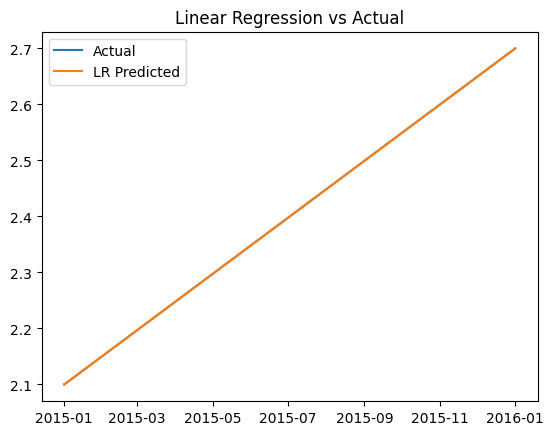

In [49]:
import matplotlib.pyplot as plt

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, pred_lr, label='LR Predicted')
plt.legend()
plt.title("Linear Regression vs Actual")
plt.show()

## 🚀 XGBoost Model

To improve performance, we use XGBoost, a powerful gradient boosting algorithm that handles non-linear relationships and temporal patterns more effectively.


#### New Version

In [50]:
df_v2 = df.copy()

#### Features Refined 

In [51]:
df_v2['lag_3'] = df_v2['Tea_Price'].shift(3)
df_v2['lag_6'] = df_v2['Tea_Price'].shift(6)

df_v2['ma_12'] = df_v2['Tea_Price'].rolling(12).mean()

df_v2['month'] = df_v2.index.month

#### Drop NaN

In [52]:
df_v2 = df_v2.dropna()

#### Final Features

In [54]:
features_v2 = [
    'lag_1','lag_2','lag_3','lag_6',
    'ma_3','ma_6','ma_12',
    'volatility','fx_return','trend','month'
]

#### Train Test Split (for v2)

In [55]:
train_v2 = df_v2[:'2014']
test_v2 = df_v2['2015':]

#### Features + Target

In [56]:
features_v2 = [
    'lag_1','lag_2','lag_3','lag_6',
    'ma_3','ma_6','ma_12',
    'volatility','fx_return','trend','month'
]

X_train = train_v2[features_v2]
y_train = train_v2['Tea_Price']

X_test = test_v2[features_v2]
y_test = test_v2['Tea_Price']

#### Xg Boost Train

In [60]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [59]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 8.6 MB/s eta 0:00:12
    --------------------------------------- 1.6/101.7 MB 5.0 MB/s eta 0:00:21
    --------------------------------------- 2.1/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.1/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 3.9/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 4.7/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 5.5/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.3/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 7.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.1/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.9/101.7 MB 4.0 MB/s eta 0:00:24



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Prediction

In [61]:
pred_xgb = xgb.predict(X_test)

#### Evaluation

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))

print("XGB MAE:", mae_xgb)
print("XGB RMSE:", rmse_xgb)

XGB MAE: 0.0886915028095246
XGB RMSE: 0.17278945716614885


#### Actual vs Predicted

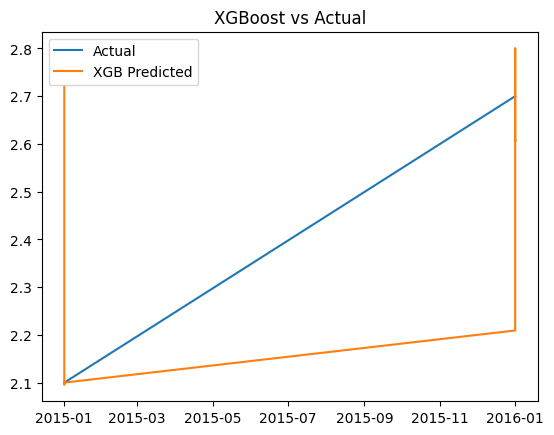

In [63]:
import matplotlib.pyplot as plt

plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, pred_xgb, label='XGB Predicted')
plt.legend()
plt.title("XGBoost vs Actual")
plt.show()

## 🏁 Final Conclusion

Among all models tested, XGBoost achieved the best performance with the lowest MAE and RMSE.

Key learnings:

* Tea prices are influenced by historical trends, FX rates, and external factors.
* Tree-based models perform well for short-term predictions but struggle with long-term trend extrapolation.
* Feature engineering plays a critical role in improving model performance.

Future Improvements:

* Incorporate export demand data
* Add more macroeconomic indicators
* Explore time-series specific models like ARIMA or LSTM


#### Save Model

In [66]:
import pickle

with open("final_tea_model.pkl", "wb") as f:
    pickle.dump(xgb, f)